## Read Shape file and check parameters

In [1]:
import geopandas as gpd

# Load shapefile
shapefile_path = r'C:\Users\Majid\Desktop\Extreme Projections\Data Processing\2-Loading and Merging Datasets\Shape files\NA_CEC_Eco_Level3\NA_CEC_Eco_Level3.shp'
regions = gpd.read_file(shapefile_path)


In [2]:
print(regions.crs)
# Output: {'proj': 'laea', 'lat_0': 45, 'lon_0': -100, 'datum': 'NAD83', 'units': 'm', 'no_defs': True}


PROJCS["Sphere_ARC_INFO_Lambert_Azimuthal_Equal_Area",GEOGCS["GCS_Sphere_ARC_INFO",DATUM["D_Sphere_ARC_INFO",SPHEROID["Sphere_ARC_INFO",6370997,0]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Azimuthal_Equal_Area"],PARAMETER["latitude_of_center",45],PARAMETER["longitude_of_center",-100],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


In [3]:
# Print the first geometry in the GeoDataFrame
print(regions.geometry.iloc[0])


POLYGON ((526634.9377999995 3437476.249399999, 534864.1213000007 3437177.003799999, 536055.1234000009 3437418.5040000007, 538938.4371000007 3438614.749, 540596.0636999998 3439495.5036999993, 544274.0013999995 3442231.0009000003, 546832.8135000002 3443537.2479999997, 547642.1258000005 3443608.2480999995, 549887.8725000005 3442601.0008000005, 553749.4993999992 3443185.5, 554583.6251999997 3443169.501, 555490.4959999993 3442919.997199999, 562308.8123000003 3439541.501700001, 564939.6894000005 3435854.5036999993, 565012.4999000002 3434134.749, 562329.8165000007 3430156.5008000005, 560602.9348000009 3428408.7540000007, 557845.4338000007 3426970.7467, 557667.3725000005 3426528.2476000004, 557719.3752999995 3426027.249399999, 558485.9334999993 3424780.2468, 559076.8143000007 3424676.249399999, 561278.6272999998 3425493, 568355.4340000004 3429875.9985000007, 570608.1848000009 3430504.4968999997, 576412.0612000003 3431119.2491999995, 578814.6846999992 3430464.003900001, 578597.2525999993 342945

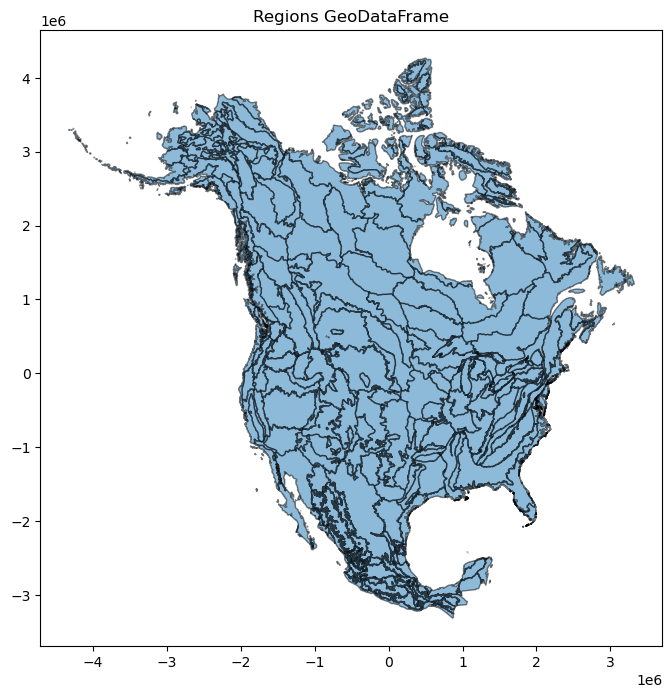

In [4]:
import matplotlib.pyplot as plt

# Plot the GeoDataFrame
fig, ax = plt.subplots(figsize=(10, 8))
regions.plot(ax=ax, edgecolor='black', alpha=0.5)

# Add title and show plot
ax.set_title('Regions GeoDataFrame')
plt.show()

## Reproject the shapefile and adjust its CRS to the NetCDF's coordinate reference system

In [5]:

from shapely.geometry import Polygon
from shapely.affinity import translate  # Import the translate function

# reproject to WGS-84 (EPSG:4326)
regions_reprojected = regions.to_crs(epsg=4326)

# Define a function to adjust longitudes to 0-360 range
def adjust_longitude(geometry):
    if geometry.is_empty:
        return geometry
    # Check if the centroid x-coordinate is negative
    if geometry.centroid.x < 0:
        # Translate the geometry by 360 degrees using shapely's translate function
        geometry = translate(geometry, xoff=360)
    return geometry

# Apply the adjustment function to the 'geometry' column
regions_reprojected['geometry'] = regions_reprojected['geometry'].apply(adjust_longitude)

# Now you can work with the adjusted GeoDataFrame without saving it
# For example, you can plot it or perform further spatial analysis
print(regions_reprojected.head())  # Example of working with the adjusted GeoDataFrame



  NA_L3CODE                             NA_L3NAME NA_L2CODE  \
0     1.1.1  Ellesmere and Devon Islands Ice Caps       1.1   
1     1.1.1  Ellesmere and Devon Islands Ice Caps       1.1   
2     1.1.1  Ellesmere and Devon Islands Ice Caps       1.1   
3     1.1.1  Ellesmere and Devon Islands Ice Caps       1.1   
4     1.1.1  Ellesmere and Devon Islands Ice Caps       1.1   

           NA_L2NAME NA_L1CODE          NA_L1NAME  \
0  ARCTIC CORDILLERA         1  ARCTIC CORDILLERA   
1  ARCTIC CORDILLERA         1  ARCTIC CORDILLERA   
2  ARCTIC CORDILLERA         1  ARCTIC CORDILLERA   
3  ARCTIC CORDILLERA         1  ARCTIC CORDILLERA   
4  ARCTIC CORDILLERA         1  ARCTIC CORDILLERA   

                                      NA_L3KEY                NA_L2KEY  \
0  1.1.1  Ellesmere and Devon Islands Ice Caps  1.1  ARCTIC CORDILLERA   
1  1.1.1  Ellesmere and Devon Islands Ice Caps  1.1  ARCTIC CORDILLERA   
2  1.1.1  Ellesmere and Devon Islands Ice Caps  1.1  ARCTIC CORDILLERA   
3  1.1

In [6]:
print(regions_reprojected.crs)
# Output: {'init': 'epsg:4326', 'no_defs': True}


EPSG:4326


In [7]:
# Print the first geometry in the GeoDataFrame
print(regions_reprojected.geometry.iloc[1])


POLYGON ((280.87826345374094 75.91607848960044, 281.00635790199397 75.8868183117622, 281.05791089158197 75.88346412174512, 281.0768562617077 75.87808778101783, 281.11529465483875 75.86155242691977, 281.13036502475717 75.8471756301326, 281.11266175829087 75.84302535816198, 281.08682913160004 75.83974366295058, 280.9632698109374 75.83874059859757, 280.9601794349493 75.8424896023715, 280.9790633886308 75.85550737350496, 280.9876883498029 75.86829194376129, 280.98664778563625 75.87226288668862, 280.9773100436271 75.87502974303274, 280.75329624673964 75.8786039195172, 280.7173102349296 75.87722901002832, 280.6469419495817 75.86953176927639, 280.591869180729 75.84720936133533, 280.590098918012 75.83867314341578, 280.628454800159 75.82715365752348, 280.6279673885199 75.81702936422249, 280.61545056371904 75.80021864866188, 280.6047863677176 75.79850708827998, 280.56746977876514 75.80006212301053, 280.46233851477876 75.81936697302983, 280.35592840028596 75.86607111909879, 280.331617646336 75.89

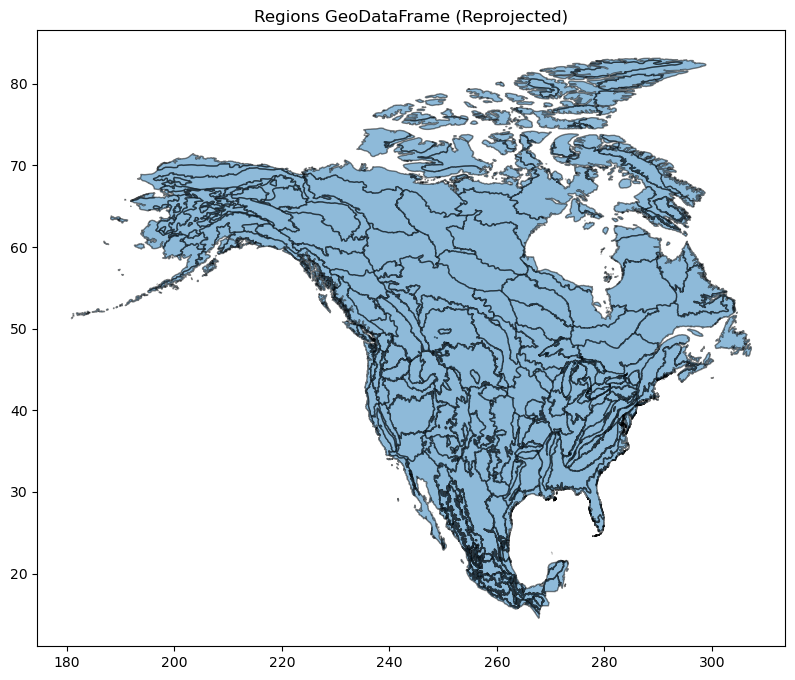

In [8]:
import matplotlib.pyplot as plt

# Plot the GeoDataFrame
fig, ax = plt.subplots(figsize=(10, 8))
regions_reprojected.plot(ax=ax, edgecolor='black', alpha=0.5)

# Add title and show plot
ax.set_title('Regions GeoDataFrame (Reprojected)')
plt.show()


In [9]:

# Get the bounding box of the shapefile
bbox = regions_reprojected.geometry.total_bounds
min_lon, min_lat, max_lon, max_lat = bbox

# Print the extracted bounds
print(f"Longitude range: {min_lon} to {max_lon}")
print(f"Latitude range: {min_lat} to {max_lat}")

Longitude range: 180.86926590909724 to 307.338225116505
Latitude range: 14.515827106773088 to 83.11044804928095


In [10]:
# Path to save the adjusted shapefile
output_shapefile = r"C:\Users\Majid\Desktop\Extreme Projections\Data Processing\3-slicing-North America\Shape files\Reprojected\NA_CEC_Eco_Level3_reprojected.shp"

# Save the adjusted GeoDataFrame to a new shapefile
regions_reprojected.to_file(output_shapefile)

C:\Anaconda3-2023.09\Lib\site-packages\pyogrio\raw.py:709: RuntimeWarning: Value 16266759936.6000004 of field Shape_Area of feature 0 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
C:\Anaconda3-2023.09\Lib\site-packages\pyogrio\raw.py:709: RuntimeWarning: Value 355136367.904999971 of field Shape_Area of feature 1 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
C:\Anaconda3-2023.09\Lib\site-packages\pyogrio\raw.py:709: RuntimeWarning: Value 7042042026.89000034 of field Shape_Area of feature 2 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
C:\Anaconda3-2023.09\Lib\site-packages\pyogrio\raw.py:709: RuntimeWarning: Value 22079347101.2999992 of field Shape_Area of feature 5 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
C:\Anaconda3-2023.09\Lib\site-packages\pyogrio\raw.py:709: R